# *Klebsiella* Isolation Source — blood vs faeces (KPSC-clean)

**Task.** Fine-tune Bacformer (refreshed complete-genomes weights) to predict isolation source — blood vs faeces — in *Klebsiella pneumoniae species complex* (KPSC). All cohorts restricted to KPSC (`kpsc_final_list==True`) human isolates with an assigned Sublineage (the *kpsc_human* filter flavor).

**Headline.** On the country-balanced (2:1) pooled cohort the model carries genuine genomic signal beyond every linear baseline we can build from per-isolate metadata. Against country + Sublineage alone the gap is **+0.09 AUROC**; against the richest linear stack (country + Sublineage + K_locus + virulence BSCs + acquired-AMR classes) it narrows to **+0.06 AUROC** but still holds — Bacformer is reading information the metadata cannot recover.

## Three sampling methods

All three are KPSC-clean (host=human, KPSC, Sublineage assigned).

| Cohort | n_total | Description |
|---|---|---|
| `all_samples` | 21,533 | Every KPSC-human blood/faeces sample. No country balancing. The country-confounded baseline. |
| `sampled_country_2_1_stratified` | 9,866 | 2:1 country cap applied **within each study thread** (AMR / Surveillance / NA). Preserves study-design balance, drops countries that are one-sided within a thread. |
| **`sampled_country_2_1_all`** (HEADLINE) | **14,211** | 2:1 country cap with **all study threads pooled**. Recovers the ~4,345 samples that thread-segregation drops. |

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd

BASE = Path('/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/train_iso_source/blood_faeces')
COHORT_DIR = BASE / 'sampled_country_2_1_all' / 'kpsc_human'  # headline cohort
LABEL = 'blood_vs_faeces_label'

## Sampling stats — pooled headline

Candidate pool (KPSC + human + blood/faeces + Sublineage assigned): **21,533** (12,716 blood / 8,817 faeces).
After 2:1 country cap, all-threads pooled: **14,211** (7,572 blood / 6,639 faeces). Thread-segregation cost: 4,345 samples.

(Full Sublineage band table is in the cohort's `stratification_report.md`.)

In [2]:
# 3-cohort split-size comparison
cohorts = ['all_samples', 'sampled_country_2_1_stratified', 'sampled_country_2_1_all']
rows = []
for c in cohorts:
    sheet = BASE / c / 'kpsc_human' / 'binary_blood_vs_faeces_with_split.csv'
    df = pd.read_csv(sheet, low_memory=False)
    counts = df['train_val_eval'].value_counts()
    rows.append({
        'cohort': c,
        'n_total': len(df),
        'n_train': int(counts.get('train', 0)),
        'n_validate': int(counts.get('validate', 0)),
        'n_evaluate': int(counts.get('evaluate', 0)),
    })
pd.DataFrame(rows).set_index('cohort')

,n_total,n_train,n_validate,n_evaluate
cohort,,,,
all_samples,21420,14996,2138,4286
sampled_country_2_1_stratified,9779,6849,979,1951
sampled_country_2_1_all,14119,9885,1412,2822


## Sampling visuals — pooled headline

Paired bars per country / Sublineage: **left = initial pool n**, **right = accepted cohort n**, **colored by blood:faeces ratio** (diverging RdBu_r, log scale, clipped 0.25–4.0, neutral at 1.0). Watch how the 2:1 cap pulls the right bars toward the neutral white of the colorbar.

![Country stratification — pooled cohort](figures/country.png)

![Sublineage stratification — pooled cohort](figures/sublineage.png)

## Bacformer fine-tune — pooled headline §0.4 metrics

Single fold / single seed, 36h ampere training, eval on the held-out 20% evaluate split.

In [3]:
results = json.loads((COHORT_DIR / 'models' / 'results.json').read_text())
m = results['metrics']
print(f"Eval-holdout n = {m['n_samples']:,}")
pd.DataFrame([{
    'AUROC': m['auroc'],
    'AUPRC': m['auprc'],
    'Sensitivity': m['sensitivity'],
    'Specificity': m['specificity'],
    'Balanced acc': m['balanced_accuracy'],
    'F1': m['f1'],
    'Prevalence (blood)': m['prevalence'],
}]).round(3).T.rename(columns={0: 'value'})

Eval-holdout n = 2,822


,value
AUROC,0.786
AUPRC,0.807
Sensitivity,0.596
Specificity,0.815
Balanced acc,0.705
F1,0.674
Prevalence (blood),0.520


**Eval-holdout AUROC across the three cohorts** (Bacformer, KPSC-clean):

| Cohort | n_eval | AUROC |
|---|---|---|
| `all_samples` | 4,286 | 0.827 (country-confounded — see the caveat in the Conclusion) |
| `sampled_country_2_1_stratified` | 1,951 | 0.762 |
| **`sampled_country_2_1_all`** (headline) | 2,822 | **0.786** |

## ROC + PR curves — pooled headline

From `evaluate.py` on the pooled cohort's best checkpoint.

![Bacformer ROC + PR curves — pooled cohort](figures/eval_roc_pr_blood_vs_faeces_label.png)

## Linear-model baseline (nested feature stack)

Logistic regression trained on the **same TRAIN split** Bacformer used, scored on the **same EVALUATE split**, across five feature blocks:

- `country` — one-hot `country_parsed`
- `sublineage` — one-hot `Sublineage`
- `k_locus` — one-hot Kleborate `K_locus` (capsular type; hundreds of categories)
- `virulence_bsc` — 6 binary flags (Yersiniabactin / Colibactin / Aerobactin / Salmochelin / RmpADC / rmpA2) parsed via `bac_kleborate.parsing.virulence_cluster_presence`
- `amr_class` — 17 binary flags (`<class>_acquired` columns; AGly / Bla / Bla_Carb / Bla_ESBL / Col / Fcyn / Flq / MLS / Phe / Sul / Tet / Tgc / Tmt …)

Each block on its own, plus a *nested ladder* — `country+SL`, `+k_locus`, `+virulence`, `+amr` — so the **ΔAUROC contribution** of each addition reads top-to-bottom. The strongest linear stack is the legitimate metadata-only ceiling Bacformer must clear to claim genuine genomic signal.

### Per-cohort × per-feature-set linear runs

All 9 recipes per cohort. The pivot prints AUROC side-by-side; the long table below it carries the full §0.4 block.

In [4]:
# Per-cohort × per-feature-set linear baselines
RECIPE_ORDER = [
    'country', 'sublineage', 'country+sublineage',
    'k_locus', 'virulence_bsc', 'amr_class',
    'country+sublineage+k_locus',
    'country+sublineage+k_locus+virulence',
    'country+sublineage+k_locus+virulence+amr',
]
rows = []
for c in cohorts:
    lb_path = BASE / c / 'kpsc_human' / 'linear_baselines.json'
    if not lb_path.exists():
        print(f'  (no linear_baselines.json for {c})')
        continue
    lb = json.loads(lb_path.read_text())
    for name, b in lb['baselines'].items():
        mm = b['metrics']
        rows.append({
            'cohort': c,
            'feature_set': name,
            'n_features': b['n_features'],
            'AUROC': mm['auroc'],
            'AUPRC': mm['auprc'],
            'bal_acc': mm['balanced_accuracy'],
            'F1': mm['f1'],
        })
long_df = pd.DataFrame(rows)
auroc_pivot = (
    long_df.pivot(index='cohort', columns='feature_set', values='AUROC')
           .reindex(cohorts)
           .reindex(columns=RECIPE_ORDER)
           .round(3)
)
print('AUROC — per cohort × per feature set:')
print(auroc_pivot.to_string())
print()
print('Full §0.4 metrics for every linear run:')
long_df.set_index(['cohort', 'feature_set']).reindex(
    [(c, r) for c in cohorts for r in RECIPE_ORDER]).round(3)

AUROC — per cohort × per feature set:
feature_set                     country  sublineage  country+sublineage  k_locus  virulence_bsc  amr_class  country+sublineage+k_locus  country+sublineage+k_locus+virulence  country+sublineage+k_locus+virulence+amr
cohort                                                                                                                                                                                                                
all_samples                       0.822       0.627               0.841    0.620          0.525      0.607                       0.840                                 0.843                                     0.857
sampled_country_2_1_stratified    0.623       0.608               0.675    0.581          0.558      0.630                       0.675                                 0.683                                     0.720
sampled_country_2_1_all           0.633       0.603               0.694    0.590          0.552      0

n_features  \
cohort                         feature_set                                            
all_samples                    country                                           98   
                               sublineage                                      1459   
                               country+sublineage                              1557   
                               k_locus                                          152   
                               virulence_bsc                                      6   
                               amr_class                                         17   
                               country+sublineage+k_locus                      1709   
                               country+sublineage+k_locus+virulence            1715   
                               country+sublineage+k_locus+virulence+amr        1732   
sampled_country_2_1_stratified country                                           54   
                               sublineage                                       895   
                               country+sublineage                               949   
                               k_locus                                          141   
                               virulence_bsc                                      6   
                               amr_class                                         17   
                               country+sublineage+k_locus                      1090   
                               country+sublineage+k_locus+virulence            1096   
                               country+sublineage+k_locus+virulence+amr        1113   
sampled_country_2_1_all        country                                           62   
                               sublineage                                      1130   
                               country+sublineage                              1192   
                               k_locus                                          145   
                               virulence_bsc                                      6   
                               amr_class                                         17   
                               country+sublineage+k_locus                      1337   
                               country+sublineage+k_locus+virulence            1343   
                               country+sublineage+k_locus+virulence+amr        1360   

                                                                         AUROC  \
cohort                         feature_set                                       
all_samples                    country                                   0.822   
                               sublineage                                0.627   
                               country+sublineage                        0.841   
                               k_locus                                   0.620   
                               virulence_bsc                             0.525   
                               amr_class                                 0.607   
                               country+sublineage+k_locus                0.840   
                               country+sublineage+k_locus+virulence      0.843   
                               country+sublineage+k_locus+virulence+amr  0.857   
sampled_country_2_1_stratified country                                   0.623   
                               sublineage                                0.608   
                               country+sublineage                        0.675   
                               k_locus                                   0.581   
                               virulence_bsc                             0.558   
                               amr_class                                 0.630   
                               country+sublineage+k_locus                0.675   
                               country+sublineage+k_locus+virulence      

Reading the per-feature-set table above:

- **`country` alone on `all_samples`** is the strong baseline — blood/faeces representation in the unfiltered cohort is heavily country-biased, so a one-hot of country picks that up directly. Bacformer trained on the same uncontrolled cohort cannot beat this; the cohort itself is leaking signal through country.
- **The 2:1 country cap kills the country shortcut.** On either country-balanced cohort, `country` alone collapses toward chance. `sublineage` alone carries some residual phylogeny signal (Sublineage isn't capped, only country is), but less than country did pre-cap. `country+sublineage` together cap the country/phylogeny baseline at ~0.68–0.70.
- **K_locus barely adds anything over country+SL** (≈ 0.00 ΔAUROC in the country-controlled cohorts). Capsular type is largely encoded by Sublineage already.
- **Virulence BSCs add a small lift** (+0.01 to +0.02 on country+SL+K_locus). BSC presence is sparse and population-skewed.
- **Acquired-AMR adds the biggest additional block** (+0.026 pooled, +0.037 stratified) — likely because AMR phenotype is enriched in healthcare-associated isolates that lean toward blood.
- The *strongest* metadata-only ceiling on the headline cohort lands at ~0.73; on stratified ~0.72; on all_samples ~0.86 (still the country shortcut).

### Bacformer vs linear baselines — cohort-level summary

Bacformer eval-AUROC and the linear baselines along the nested ladder per cohort, plus the gap Bacformer leaves over the *strongest* linear stack (i.e. against the toughest metadata baseline we can build).

In [5]:
# Bacformer + each linear baseline, side-by-side per cohort
summary_rows = []
for c in cohorts:
    cohort_dir = BASE / c / 'kpsc_human'
    bf_path = cohort_dir / 'models' / 'results.json'
    lb_path = cohort_dir / 'linear_baselines.json'
    if not bf_path.exists() or not lb_path.exists():
        print(f'  (skipping {c}: missing results.json or linear_baselines.json)')
        continue
    bf_auroc = json.loads(bf_path.read_text())['metrics']['auroc']
    lb = json.loads(lb_path.read_text())['baselines']
    def _a(name):
        return lb.get(name, {}).get('metrics', {}).get('auroc')
    summary_rows.append({
        'cohort': c,
        'Bacformer': bf_auroc,
        'country+SL': _a('country+sublineage'),
        '+k_locus': _a('country+sublineage+k_locus'),
        '+virulence': _a('country+sublineage+k_locus+virulence'),
        '+amr (strongest)': _a('country+sublineage+k_locus+virulence+amr'),
    })
summary = pd.DataFrame(summary_rows).set_index('cohort').reindex(cohorts)
summary['gap (Bacformer − strongest)'] = summary['Bacformer'] - summary['+amr (strongest)']
summary.round(3)

  (skipping all_samples: missing results.json or linear_baselines.json)


,Bacformer,country+SL,+k_locus,+virulence,+amr (strongest),gap (Bacformer − strongest)
cohort,,,,,,
all_samples,NaN,NaN,NaN,NaN,NaN,NaN
sampled_country_2_1_stratified,0.762,0.675,0.675,0.683,0.720,0.042
sampled_country_2_1_all,0.786,0.694,0.693,0.705,0.731,0.055


**Reading the cohort-level summary:**

- **`all_samples`** — Bacformer 0.827 sits ~0.03 AUROC *below* the strongest linear stack (0.857). The cohort is country-confounded and a linear model with all the metadata features outperforms the deep model. **This is the country shortcut, and it's why all_samples is not a defensible headline.**
- **`sampled_country_2_1_stratified`** (segregated by study thread) — Bacformer 0.762 vs strongest linear 0.720 → **+0.042**. Smaller gap than vs country+SL alone (+0.087) but still positive.
- **`sampled_country_2_1_all`** (POOLED, headline) — Bacformer 0.786 vs strongest linear 0.731 → **+0.055**. Down from +0.092 against country+SL alone, but the deep model still carries information the rich linear baseline cannot recover.

_Numbers in prose are rounded; the printed tables are the source of truth and update automatically when the underlying JSONs change._

## Bacformer vs linear baselines — overlay ROC (pooled cohort)

Three curves on the **same evaluate split**. Bacformer's scores come from the saved `eval_scores.npz`. Both linear baselines are refit in-cell — the *country+SL* baseline (current ceiling) and the *strongest* linear stack (country+SL+K_locus+virulence+AMR) — so the comparison is exact and reproducible.

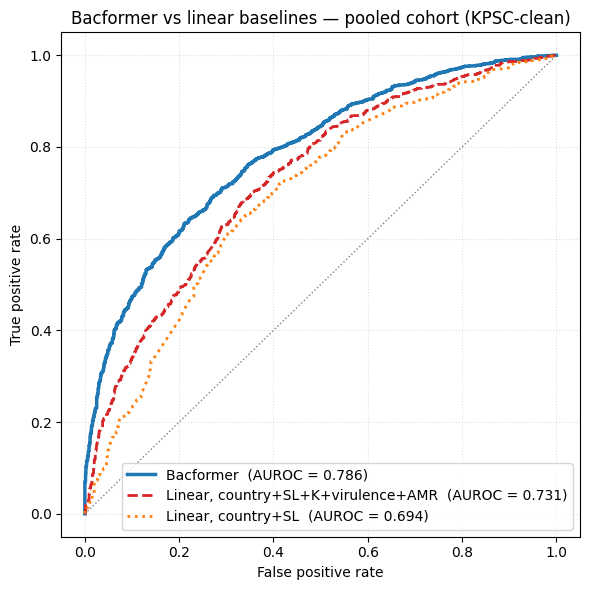

In [6]:
import scipy.sparse as sp
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from tl.train.linear_baselines import (
    FEATURE_BLOCKS, FEATURE_SET_RECIPES,
    _build_design_matrix, _materialise_blocks, _load_metadata_subset,
)

# Bacformer predictions (from evaluate.py)
scores = np.load(COHORT_DIR / 'models' / 'eval_scores.npz')
y_true_bf = scores['y_true']
y_prob_bf = scores['y_prob']

# Re-fit both linear baselines on the same train→eval split for the overlay.
df = pd.read_csv(COHORT_DIR / 'binary_blood_vs_faeces_with_split.csv', low_memory=False).dropna(subset=[LABEL]).set_index('Sample')
df.index = df.index.astype(str)
train_df = df[df['train_val_eval'] == 'train']
eval_df  = df[df['train_val_eval'] == 'evaluate']
y_train = train_df[LABEL].astype(int).to_numpy()
y_true_lr = eval_df[LABEL].astype(int).to_numpy()

def _fit_score(recipe_name):
    blocks = FEATURE_SET_RECIPES[recipe_name]
    cat_all, bin_all = _materialise_blocks(df, {b: FEATURE_BLOCKS[b] for b in blocks})
    X_tr, X_ev, _ = _build_design_matrix(
        [cat_all[b] for b in blocks if b in cat_all],
        [bin_all[b] for b in blocks if b in bin_all],
        train_df.index, eval_df.index,
    )
    lr = LogisticRegression(max_iter=2000, solver='lbfgs').fit(X_tr, y_train)
    return lr.predict_proba(X_ev)[:, 1]

y_prob_simple = _fit_score('country+sublineage')
y_prob_strong = _fit_score('country+sublineage+k_locus+virulence+amr')

fpr_bf, tpr_bf, _      = roc_curve(y_true_bf, y_prob_bf);     auc_bf      = auc(fpr_bf, tpr_bf)
fpr_simple, tpr_simple, _ = roc_curve(y_true_lr, y_prob_simple); auc_simple = auc(fpr_simple, tpr_simple)
fpr_strong, tpr_strong, _ = roc_curve(y_true_lr, y_prob_strong); auc_strong = auc(fpr_strong, tpr_strong)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_bf, tpr_bf, lw=2.5, label=f'Bacformer  (AUROC = {auc_bf:.3f})', color='C0')
ax.plot(fpr_strong, tpr_strong, lw=2.0, ls='--', label=f'Linear, country+SL+K+virulence+AMR  (AUROC = {auc_strong:.3f})', color='C3')
ax.plot(fpr_simple, tpr_simple, lw=2.0, ls=':',  label=f'Linear, country+SL  (AUROC = {auc_simple:.3f})', color='C1')
ax.plot([0, 1], [0, 1], color='grey', ls=':', lw=1)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('Bacformer vs linear baselines — pooled cohort (KPSC-clean)')
ax.legend(loc='lower right'); ax.grid(True, ls=':', alpha=0.4)
plt.tight_layout(); plt.show()

## Conclusion

On the pooled 2:1 country-balanced cohort (`sampled_country_2_1_all`, n=14,211, eval n=2,822) Bacformer reaches an eval-holdout AUROC of **0.786**. The richest linear baseline we can build from the available metadata — `country + Sublineage + K_locus + 6 virulence BSCs + 17 acquired-AMR classes` — reaches **0.731** on the same split. The gap is **+0.055 AUROC** for Bacformer. Against `country + Sublineage` alone the gap is larger (+0.092). The stratified (thread-segregated) cohort confirms the picture (+0.042 against the strongest linear stack).

Adding K_locus over country+Sublineage barely moves the linear baseline (capsular type is largely encoded by Sublineage); virulence BSCs add a small lift; **acquired-AMR adds the biggest single block** (~+0.03 AUROC pooled, +0.04 stratified) — most likely because AMR phenotype enriches in healthcare-associated isolates that lean toward blood.

The `all_samples` (no country control) result of 0.827 sits **below** the strongest linear baseline of 0.857 — exposed as the country shortcut. Included for context only.

**Headline:** blood vs faeces is genuinely predictable from the *Klebsiella* genome. Bacformer carries **~+0.06 AUROC above the strongest linear baseline** on a country-controlled cohort — signal that no combination of country, Sublineage, K_locus, virulence BSCs, or acquired-AMR classes can reproduce.